Synthetic Dataset and Geometric Support Analysis

In this section, we construct a synthetic 2D descriptor space to study interpolation, extrapolation, and uncertainty behavior in machine learning models.

A smooth nonlinear property surface is generated over the full descriptor domain. Training samples are intentionally restricted to only part of the domain, and a sparse local region (hole) is introduced to simulate weak data support.

This setup allows us to investigate: how machine learning models behave in supported vs unsupported regions,the relationship between geometric distance and uncertainty,
and why smooth predictions alone may not imply reliability.

Training dataset shape: (131, 3)


,x1,x2,target
0,0.296912,-1.100585,0.956229
1,-2.365558,0.901596,-0.324646
2,-1.042706,-0.218283,-0.432461
3,0.117470,-0.347077,1.267341
4,-0.687253,-1.758044,-0.729904


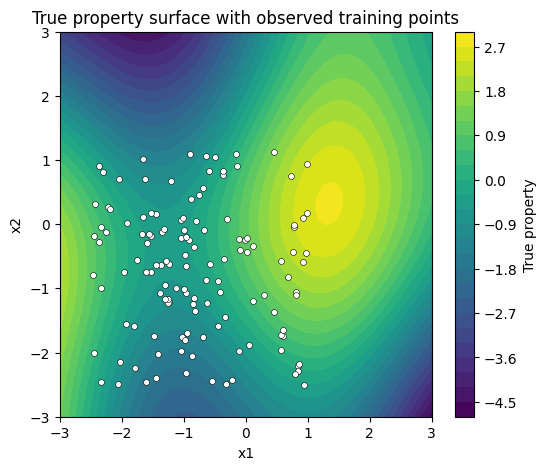

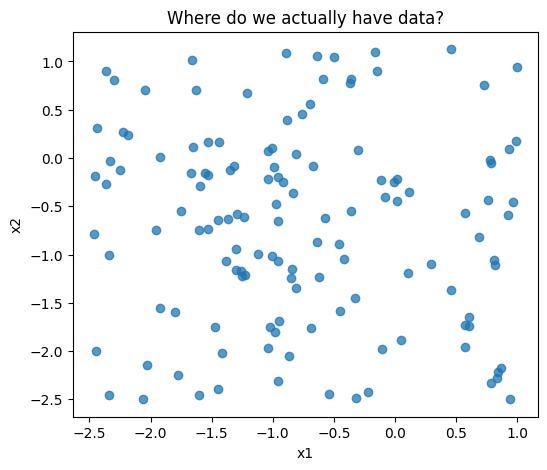

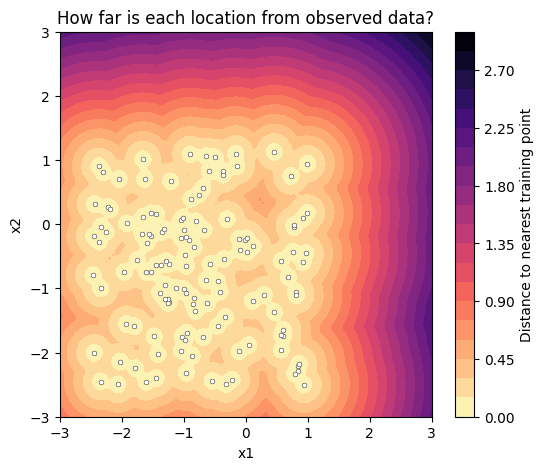


Questions to think about:
1. Which parts of the domain are genuinely covered by data?
2. Where would later model predictions be interpolation, and where would they be extrapolation?
3. Is a smooth-looking prediction automatically trustworthy everywhere?
4. Does geometric distance from training data already warn us about ignorance?
5. How should uncertainty behave near the hole and near the outer edges?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2029)

# We generate a smooth synthetic property surface in 2D descriptor space.
# The trap is that training data will cover only part of this space.

def true_property(x1, x2):
    return (
        1.6 * np.sin(1.2 * x1)
        + 1.1 * np.cos(0.9 * x2)
        + 0.25 * x1 * x2
        - 0.08 * x2**2
    )

# Full descriptor domain
x1_grid = np.linspace(-3, 3, 120)
x2_grid = np.linspace(-3, 3, 120)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Y_true = true_property(X1, X2)

# Training points only in a restricted region
n_train = 140
x1_train = rng.uniform(-2.5, 1.0, n_train)
x2_train = rng.uniform(-2.5, 1.2, n_train)

# Carve out a sparse hole to make support geometry more interesting
mask = ~((x1_train > -0.3) & (x1_train < 0.7) & (x2_train > -0.2) & (x2_train < 0.8))
x1_train = x1_train[mask]
x2_train = x2_train[mask]

y_train = true_property(x1_train, x2_train) + rng.normal(0, 0.15, len(x1_train))

df_train = pd.DataFrame({
    "x1": x1_train,
    "x2": x2_train,
    "target": y_train
})

print("Training dataset shape:", df_train.shape)
display(df_train.head())

plt.figure(figsize=(6, 5))
plt.contourf(X1, X2, Y_true, levels=25, cmap="viridis")
plt.colorbar(label="True property")
plt.scatter(x1_train, x2_train, c="white", s=18, edgecolors="black", linewidths=0.4)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("True property surface with observed training points")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(x1_train, x2_train, alpha=0.75)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Where do we actually have data?")
plt.show()

# Distance from each grid point to nearest training point.
# This is not a model uncertainty, but it is a geometric clue about support.
grid_points = np.column_stack([X1.ravel(), X2.ravel()])
train_points = np.column_stack([x1_train, x2_train])

dists = np.sqrt(((grid_points[:, None, :] - train_points[None, :, :]) ** 2).sum(axis=2))
nearest_dist = dists.min(axis=1).reshape(X1.shape)

plt.figure(figsize=(6, 5))
plt.contourf(X1, X2, nearest_dist, levels=25, cmap="magma_r")
plt.colorbar(label="Distance to nearest training point")
plt.scatter(x1_train, x2_train, c="white", s=12, edgecolors="black", linewidths=0.3)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("How far is each location from observed data?")
plt.show()

print("\nQuestions to think about:")
print("1. Which parts of the domain are genuinely covered by data?")
print("2. Where would later model predictions be interpolation, and where would they be extrapolation?")
print("3. Is a smooth-looking prediction automatically trustworthy everywhere?")
print("4. Does geometric distance from training data already warn us about ignorance?")
print("5. How should uncertainty behave near the hole and near the outer edges?")

Gaussian Process Regression: Uncertainty Analysis
A Gaussian Process Regression (GPR) model with an RBF kernel was trained using the available training samples to investigate model behavior across the descriptor space.

$$
k(x,x') = \sigma_f^2 \exp\left(-\frac{\|x-x'\|^2}{2l^2}\right)
$$

Predictions were generated over the full descriptor grid, and the predictive standard deviation returned by the Gaussian Process model was used to analyze uncertainty behavior in supported and unsupported regions of descriptor space.

In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Prepare data
X_train = np.column_stack([x1_train, x2_train])

# Kernel
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 10))

# Model
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.02, n_restarts_optimizer=5)

# Train
gpr.fit(X_train, y_train)

# Predict on grid
X_grid = np.column_stack([X1.ravel(), X2.ravel()])
y_pred, y_std = gpr.predict(X_grid, return_std=True)

Y_pred = y_pred.reshape(X1.shape)
Y_std = y_std.reshape(X1.shape)

GPR Predictive Mean:

The predictive mean obtained from the Gaussian Process model represents the estimated property surface across the descriptor space.

The smooth variation in the prediction surface arises from the RBF kernel, which assumes strong correlations between nearby points in descriptor space.

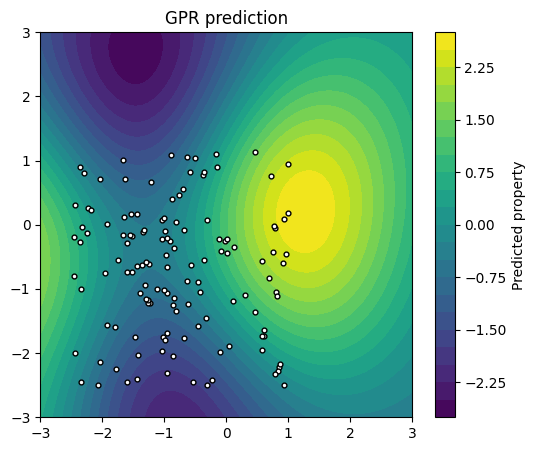

In [3]:
plt.figure(figsize=(6,5))
plt.contourf(X1, X2, Y_pred, levels=25, cmap="viridis")
plt.colorbar(label="Predicted property")
plt.scatter(x1_train, x2_train, c="white", s=12, edgecolors="black")
plt.title("GPR prediction")
plt.show()

Observation

The prediction surface remains smooth across the entire domain, including regions with limited or no training data. While interpolation regions near observed samples are expected to be more reliable, extrapolation regions may still appear visually smooth despite having weaker support.

This highlights that smooth predictions alone are not sufficient indicators of model reliability, motivating the need for uncertainty analysis.

GPR Predictive Uncertainty

In addition to the predictive mean, Gaussian Process Regression provides an estimate of predictive uncertainty through the predictive standard deviation.

The uncertainty map is used to analyze model confidence across the descriptor space and to identify regions where predictions are likely to be less reliable.

Low uncertainty is expected near densely sampled training regions, while higher uncertainty is expected in sparse or unsupported regions where extrapolation occurs.

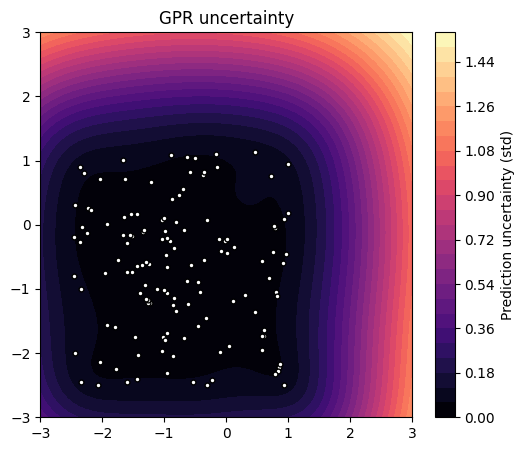

In [4]:
plt.figure(figsize=(6,5))
plt.contourf(X1, X2, Y_std, levels=25, cmap="magma")
plt.colorbar(label="Prediction uncertainty (std)")
plt.scatter(x1_train, x2_train, c="white", s=12, edgecolors="black")
plt.title("GPR uncertainty")
plt.show()

Observation

The uncertainty is lowest near the observed training samples and gradually increases as the distance from the training data increases.

High uncertainty is clearly observed near the outer boundaries of the descriptor domain,
regions far from observed samples,
and locally sparse regions.

Although the predictive mean surface remains visually smooth across the domain, the uncertainty map reveals where the model lacks strong support from training data.

This demonstrates an important characteristic of Gaussian Process Regression:

Interpolation regions typically exhibit lower uncertainty,
while extrapolation regions exhibit significantly higher uncertainty.

The uncertainty distribution also shows strong correlation with geometric distance from the training data, indicating that regions farther from observed samples are associated with reduced model confidence.

Kernel Density Estimation (KDE)

To analyze the local density of training samples in descriptor space,KDE was applied to the training data.

KDE provides a smooth estimate of the probability density distribution of the observed samples. Regions with high KDE values correspond to densely populated regions of descriptor space, while low KDE values indicate sparse or weakly supported regions.

Unlike Gaussian Process uncertainty, KDE does not depend on the predictive model itself. Instead, it provides a purely data-driven measure of local training support.

A Gaussian kernel was used for density estimation.

In [5]:
from sklearn.neighbors import KernelDensity
kde = KernelDensity(kernel='gaussian', bandwidth=0.4)
kde.fit(X_train)

KernelDensity(bandwidth=0.4)

In [6]:
log_density = kde.score_samples(X_grid)
density = np.exp(log_density).reshape(X1.shape)

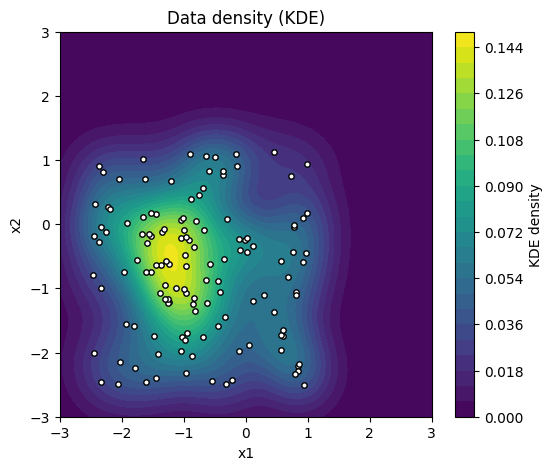

In [7]:
plt.figure(figsize=(6,5))
plt.contourf(X1, X2, density, levels=25, cmap="viridis")
plt.colorbar(label="KDE density")
plt.scatter(x1_train, x2_train, c="white", s=15, edgecolors="black")
plt.title("Data density (KDE)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Observation:

The KDE map shows that the training samples are unevenly distributed across the descriptor space. Dense regions are concentrated near the center of the sampled domain, while density decreases near the outer boundaries and sparse regions.

The intentionally introduced local hole is also reflected through reduced density values.

Comparison between the KDE density map and the GPR uncertainty map shows a strong inverse relationship:

Regions with high data density generally exhibit lower uncertainty,
whereas sparse regions correspond to elevated uncertainty.

This demonstrates that local data support plays an important role in determining model confidence.

Convex Hull Analysis

To distinguish interpolation regions from extrapolation regions, a convex hull was constructed around the training samples in descriptor space.

The convex hull represents the smallest convex region containing all observed training points. Grid points lying inside the hull are considered geometrically supported interpolation regions, whereas points outside the hull correspond to extrapolation regions.

This analysis provides a simple geometric framework for studying how prediction error and uncertainty behave inside and outside the supported training domain.

In [8]:
from scipy.spatial import ConvexHull

points = np.column_stack([x1_train, x2_train])


hull = ConvexHull(points)

In [9]:
from scipy.spatial import Delaunay


tri = Delaunay(points[hull.vertices])


inside_hull = tri.find_simplex(X_grid) >= 0
inside_hull = inside_hull.reshape(X1.shape)

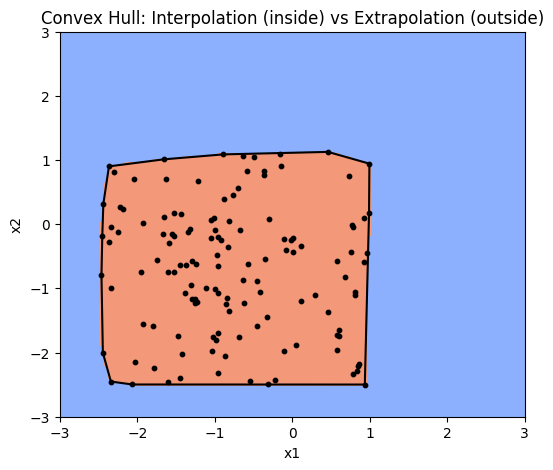

In [10]:
plt.figure(figsize=(6,5))
plt.contourf(X1, X2, inside_hull, levels=1, cmap="coolwarm")
plt.scatter(x1_train, x2_train, c="black", s=10)

for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'k-')

plt.title("Convex Hull: Interpolation (inside) vs Extrapolation (outside)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Observation:
Predictions inside the hull primarily correspond to interpolation, where the model estimates values between observed samples. In contrast, predictions outside the hull represent extrapolation, where the model relies more strongly on learned smoothness assumptions rather than nearby observations.

In [11]:
error = np.abs(Y_pred - Y_true)
print(error)

[[0.71433829 0.65935138 0.60452826 ... 4.0386418  4.15937689 4.27810053]
 [0.70496932 0.65094178 0.59709585 ... 3.9744091  4.09348389 4.21056735]
 [0.69612961 0.64302226 0.59011404 ... 3.90920407 4.02659349 4.14201241]
 ...
 [1.80581816 1.79225234 1.78070523 ... 0.40632645 0.44618568 0.48369886]
 [1.87917562 1.86598757 1.8548411  ... 0.40081595 0.44100733 0.47883174]
 [1.95326539 1.94048156 1.92976107 ... 0.39404817 0.43454055 0.47264619]]


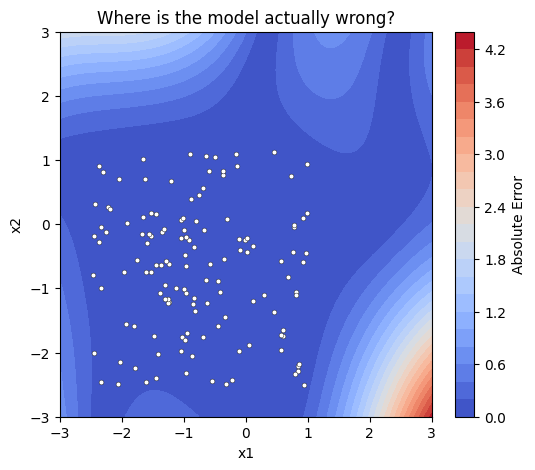

In [12]:
plt.figure(figsize=(6,5))
plt.contourf(X1, X2, error, levels=25, cmap="coolwarm")
plt.colorbar(label="Absolute Error")
plt.scatter(x1_train, x2_train, c="white", s=12, edgecolors="black", linewidths=0.3)
plt.title("Where is the model actually wrong?")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Observation:
Low prediction errors are observed throughout most of the sampled region where the model performs interpolation between nearby observations. In contrast, prediction error increases significantly toward the outer boundaries of the descriptor space where the model must extrapolate beyond the supported training domain.

The largest errors occur in regions farthest from the training samples, particularly near the lower-right corner of the domain. This behavior demonstrates that although the GPR prediction surface remains smooth in extrapolation regions, the predictions themselves may become substantially less accurate.

Interestingly, some regions outside the training domain still exhibit relatively small error despite the absence of nearby data. This occurs because the underlying synthetic function is smooth, allowing the Gaussian Process model to continue learned trends reasonably well over short extrapolation distances.

However, even in these low-error extrapolation regions, the predictive uncertainty remains comparatively high. This indicates that the model is still less confident in these predictions despite producing numerically accurate results. Therefore, low prediction error in a specific region does not necessarily imply high model confidence or strong data support.

Train,Validation,Test Split for Model Evaluation

The earlier analyses focused primarily on understanding prediction behavior, uncertainty distribution, and interpolation versus extrapolation across the full descriptor domain.

To evaluate the generalization performance of the Gaussian Process model on unseen data, the dataset was next divided into:

training,
validation,
and test subsets

In [13]:
from sklearn.model_selection import train_test_split


X_temp, X_test, y_temp, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

X_train_split, X_val, y_train_split, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)


print("Train:", X_train_split.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (78, 2)
Val: (26, 2)
Test: (27, 2)


GPR Prediction with Uncertainty Bounds

After splitting the dataset into training, validation, and test subsets, the Gaussian Process Regression model was retrained using only the training subset.

Predictions were then generated across the full descriptor grid to visualize:

The predictive mean,
and the associated uncertainty bounds.



μ(x)±2σ(x)

For a Gaussian distribution, this interval approximately corresponds to a 95% confidence region around the predicted mean.

In [14]:
gpr = GaussianProcessRegressor(kernel=kernel, alpha=0.02, n_restarts_optimizer=5)
gpr.fit(X_train_split, y_train_split)

GaussianProcessRegressor(alpha=0.02, kernel=1**2 * RBF(length_scale=1),
                         n_restarts_optimizer=5)

In [15]:
y_train_pred = gpr.predict(X_train_split)
y_val_pred = gpr.predict(X_val)
y_test_pred = gpr.predict(X_test)

In [16]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_train = np.sqrt(mean_squared_error(y_train_split, y_train_pred))
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Train RMSE:", rmse_train)
print("Validation RMSE:", rmse_val)
print("Test RMSE:", rmse_test)

Train RMSE: 0.12487604657692748
Validation RMSE: 0.17612668698413692
Test RMSE: 0.20668220359954478


In [17]:
y_pred, y_std = gpr.predict(X_grid, return_std=True)

Y_pred = y_pred.reshape(X1.shape)
Y_std = y_std.reshape(X1.shape)

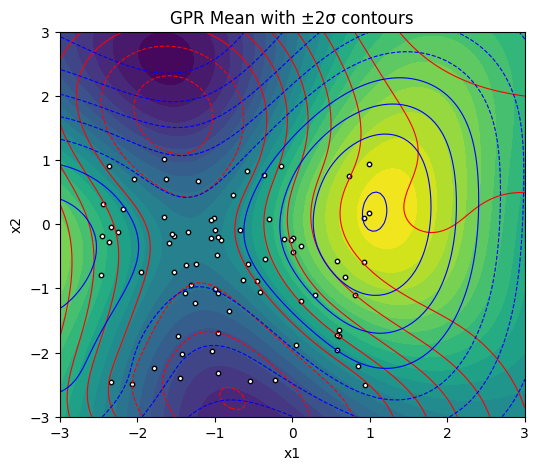

In [ ]:
upper = Y_pred + 2 * Y_std
lower = Y_pred - 2 * Y_std

plt.figure(figsize=(6,5))
plt.contourf(X1, X2, Y_pred, levels=25, cmap="viridis")
plt.contour(X1, X2, upper, levels=10, colors='red', linewidths=0.8)
plt.contour(X1, X2, lower, levels=10, colors='blue', linewidths=0.8)

plt.scatter(X_train_split[:,0], X_train_split[:,1], c="white", s=10, edgecolors="black")
plt.title("GPR Mean with ±2σ contours")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

Observation

The filled contour represents the predictive mean surface learned by the Gaussian Process model, while the red and blue contour lines represent the upper and lower uncertainty bounds respectively.

Near the training samples, the upper and lower contours remain relatively close to the predictive mean, indicating lower uncertainty and stronger confidence in the predictions. As the distance from the training data increases, the separation between the contours becomes larger, reflecting increased predictive uncertainty.

The widening of the uncertainty bounds is especially visible near the outer regions of the descriptor space where extrapolation occurs. This demonstrates that the model becomes progressively less certain in regions with weaker training support.

The uncertainty contours therefore provide an intuitive visualization of how prediction confidence changes throughout the descriptor domain

Comparison of Predictions Inside and Outside the Convex Hull
To compare model behavior in interpolation and extrapolation regions, the descriptor space was divided into: points lying inside the convex hull of the training data,
and points lying outside the hull.





In [ ]:
inside_mask = inside_hull
outside_mask = ~inside_mask

In [ ]:
from sklearn.metrics import mean_squared_error


y_true_flat = Y_true.ravel()
y_pred_flat = Y_pred.ravel()
inside_flat = inside_mask.ravel()
outside_flat = outside_mask.ravel()


rmse_inside = np.sqrt(mean_squared_error(y_true_flat[inside_flat], y_pred_flat[inside_flat]))


rmse_outside = np.sqrt(mean_squared_error(y_true_flat[outside_flat], y_pred_flat[outside_flat]))


rmse_total = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))

print("RMSE inside hull:", rmse_inside)
print("RMSE outside hull:", rmse_outside)
print("Total RMSE:", rmse_total)

RMSE inside hull: 0.08790365454915132
RMSE outside hull: 0.8450222534207015
Total RMSE: 0.6922116621586529


Observation:
The RMSE inside the convex hull is significantly smaller than the RMSE outside the hull, indicating that the model performs more accurately in interpolation regions supported by nearby observations.

Although some extrapolation regions still exhibit relatively low local prediction error, particularly near the hull boundary, the overall prediction error outside the hull is substantially larger on average. This occurs because the Gaussian Process model can extend smooth trends reasonably well over short extrapolation distances, but prediction accuracy deteriorates progressively in regions farther from the training support.

These results demonstrate that smooth-looking extrapolative predictions are not necessarily reliable throughout the unsupported domain, even if certain local regions happen to exhibit low error.

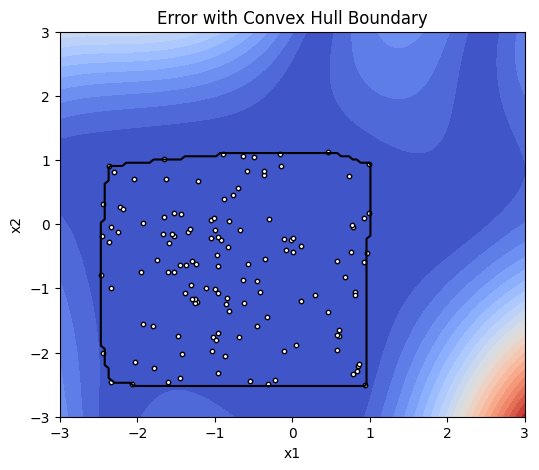

In [ ]:
plt.figure(figsize=(6,5))
plt.contourf(X1, X2, error, levels=25, cmap="coolwarm")

# Overlay boundary
plt.contour(X1, X2, inside_mask, levels=[0.5], colors='black')

plt.scatter(x1_train, x2_train, c="white", s=10, edgecolors="black")
plt.title("Error with Convex Hull Boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [ ]:
# Standard deviation (uncertainty)
std_inside = Y_std[inside_mask].mean()
std_outside = Y_std[outside_mask].mean()

print("Mean uncertainty (inside hull):", std_inside)
print("Mean uncertainty (outside hull):", std_outside)

Mean uncertainty (inside hull): 0.06330362226021581
Mean uncertainty (outside hull): 0.5732574163786737


Observation

Here we observe that the mean predictive uncertainty inside the convex hull is significantly smaller than the uncertainty outside the hull. This indicates that the Gaussian Process model is more confident in interpolation regions where nearby training samples provide stronger geometric support.

In contrast, uncertainty increases substantially outside the convex hull because the model must extrapolate beyond the observed training domain. In these regions, predictions are influenced less by nearby observations and more by the smooth trends learned from the training data.

Interestingly, although some extrapolation regions may still exhibit relatively low prediction error, the uncertainty remains high. This shows that the model correctly identifies these regions as weakly supported despite occasionally producing accurate predictions.

Overall, the uncertainty analysis demonstrates that predictive confidence strongly depends on the availability of nearby training data and the geometric support of the descriptor space

Comparison of Predictions Inside and Outside the high KDE and low KDE To compare model behavior in interpolation and extrapolation regions.

To investigate the influence of local training density on model behavior, the KDE density distribution was used to divide the descriptor space into sparse and dense regions.

A percentile-based threshold was applied to the KDE values:points with density below the threshold were classified as low-density regions,
while points above the threshold were classified as high-density regions.

Unlike the convex hull, which provides a global interpolation/extrapolation boundary, KDE provides a local measure of data support throughout the descriptor space.

In [ ]:

density_flat = density.ravel()


threshold = np.percentile(density_flat, 40)

low_kde_mask = density <= threshold
high_kde_mask = density > threshold

In [ ]:
std_low_kde = Y_std[low_kde_mask].mean()
std_high_kde = Y_std[high_kde_mask].mean()

print("Uncertainty (low KDE):", std_low_kde)
print("Uncertainty (high KDE):", std_high_kde)

Uncertainty (low KDE): 0.8204512673161607
Uncertainty (high KDE): 0.12580309908316217


 Observation

The predictive uncertainty is significantly larger in low-density KDE regions compared to high-density regions. This indicates that the Gaussian Process model becomes substantially less confident in sparsely sampled areas of descriptor space.

In high-density regions, the presence of many nearby training samples provides strong local support, resulting in lower uncertainty and more stable predictions. In contrast, low-density regions contain weaker local information, forcing the model to rely more heavily on extrapolative behavior and learned smoothness assumptions.

This result demonstrates that predictive uncertainty is strongly influenced not only by the global interpolation/extrapolation structure defined by the convex hull, but also by the local density of training samples within the descriptor space.

The large uncertainty difference between low- and high-density regions further confirms that KDE is an effective indicator of local model support and prediction confidence.

In [ ]:
from sklearn.metrics import mean_squared_error

y_true_flat = Y_true.ravel()
y_pred_flat = Y_pred.ravel()
low_flat = low_kde_mask.ravel()
high_flat = high_kde_mask.ravel()

rmse_low_kde = np.sqrt(mean_squared_error(y_true_flat[low_flat], y_pred_flat[low_flat]))
rmse_high_kde = np.sqrt(mean_squared_error(y_true_flat[high_flat], y_pred_flat[high_flat]))

print("RMSE (low KDE):", rmse_low_kde)
print("RMSE (high KDE):", rmse_high_kde)

RMSE (low KDE): 1.071780878425074
RMSE (high KDE): 0.1810675964264716


Observation

The RMSE in low-density KDE regions is significantly larger than the RMSE in high-density regions. This indicates that prediction accuracy deteriorates in sparsely sampled areas of descriptor space where local training support is weak.

In contrast, densely sampled regions exhibit substantially lower prediction error because nearby observations provide stronger constraints for interpolation.

Together with the uncertainty analysis, this result demonstrates a strong relationship between local data density, predictive confidence, and model accuracy:

low-density regions tend to exhibit both higher uncertainty and larger prediction error,
whereas high-density regions generally show lower uncertainty and improved predictive performance.

This behavior highlights the importance of adequate training coverage for obtaining reliable machine learning predictions across descriptor space.

Analysis of Model Reliability and Data Geometry

The performance of the Gaussian Process Regression (GPR) model was evaluated not only through standard error metrics but also by analyzing the relationship between predictive accuracy and the spatial distribution of the training data. The following conclusions were drawn:

1. Data Density as a Determinant of Model Regime

Local data density serves as a primary indicator of whether the model is operating in an interpolation or extrapolation regime. In high-density regions, the model leverages proximal data points to anchor its predictions, whereas in sparse regions, it must rely on the underlying kernel's prior assumptions.

2. Uncertainty Quantification and Predictive Integrity

A significant advantage of GPR is its ability to quantify epistemic uncertainty. While the predictive surface may remain smooth across the entire domain, the model effectively identifies its own limitations by exhibiting high predictive variance (uncertainty) in areas devoid of training data. This ensures that the model's "honesty" remains intact even when its precision decreases.

3. Correlation between Density and Error Metrics

Analysis using Kernel Density Estimation (KDE) confirms a strong inverse correlation between data density and error. Regions identified with high data density consistently yielded a lower Root Mean Square Error (RMSE)

4. Limitations of Geometric Boundaries (Convex Hull)

While the Convex Hull is often used to define the boundary of the interpolation region, this study finds it insufficient for identifying "internal" extrapolation. If a region within the hull contains no data (a "hole"), the model's reliability there is equivalent to that of an extrapolation zone. Therefore, local density is a more robust metric for assessing model applicability than simple geometric boundaries.
